In [13]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from ipywidgets import interact, IntSlider
from multiprocessing import Pool, cpu_count

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib.projections")

In [10]:
# Function to process each subgraph layout
def process_subgraph(args):
    idx, subgraph, x_offset, y_offset = args
    try:
        hierarchy = list(nx.topological_sort(subgraph))
        sub_pos = {node: (x_offset + i * 2, y_offset - idx * 5) for i, node in enumerate(hierarchy)}
        return sub_pos, len(hierarchy)
    except nx.NetworkXUnfeasible:
        sub_pos = nx.spring_layout(subgraph, seed=42, k=0.8)
        sub_pos = {node: (x_offset + x, y_offset - idx * 5 - y) for node, (x, y) in sub_pos.items()}
        return sub_pos, len(sub_pos)


def plot_filtered_graph(threshold):
    filtered_edges = [(u, v) for u, v, data in G.edges(data=True) if matrix.loc[u, v] >= threshold]
    filtered_nodes = set(u for u, v in filtered_edges).union(v for u, v in filtered_edges)
    
    filtered_G = G.edge_subgraph(filtered_edges).copy()
    
    # Remove isolated nodes
    isolated_nodes = set(filtered_G.nodes) - filtered_nodes
    filtered_G.remove_nodes_from(isolated_nodes)
    
    # Plot the filtered graph
    plt.figure(figsize=(16, 12))
    nx.draw(filtered_G, pos, with_labels=True, node_color='skyblue', node_size=2000, font_size=10, font_color='black', font_weight='bold', edge_color='gray')
    edge_labels = nx.get_edge_attributes(filtered_G, 'weight')
    nx.draw_networkx_edge_labels(filtered_G, pos, edge_labels=edge_labels)
    plt.title(f'Graph with threshold >= {threshold}')
    plt.show()

In [7]:
# Load the matrix from the CSV file without column names
matrix = pd.read_csv('Ergebnisse/LP_Verständlichkeit.csv', header=None)

# Ensure it's a square matrix
if matrix.shape[0] != matrix.shape[1]:
    raise ValueError("The matrix must be square (m*m).")

# Assign default indices and column names if missing
matrix.index = range(matrix.shape[0])
matrix.columns = range(matrix.shape[1])

# Create a directed graph from the adjacency matrix
G = nx.from_pandas_adjacency(matrix, create_using=nx.DiGraph)

# Separate connected components to prevent overlap
subgraphs = [G.subgraph(c).copy() for c in nx.weakly_connected_components(G)]

In [11]:
# Use multiprocessing to calculate positions
pos = {}
x_offset = 0
y_offset = 0
args = [(idx, subgraph, x_offset + idx * 10, y_offset) for idx, subgraph in enumerate(subgraphs)]

with Pool(cpu_count()) as pool:
    results = pool.map(process_subgraph, args)

for sub_pos, length in results:
    pos.update(sub_pos)
    x_offset += length * 3
    y_offset -= 10

# Reverse y-coordinates to ensure upward direction
pos = {node: (x, -y) for node, (x, y) in pos.items()}

In [14]:
# Interactive plot with threshold slider
max_weight = matrix.max().max()
interact(plot_filtered_graph, threshold=IntSlider(min=0, max=int(max_weight), step=1, value=4))

interactive(children=(IntSlider(value=4, description='threshold', max=6), Output()), _dom_classes=('widget-int…

<function __main__.plot_filtered_graph(threshold)>

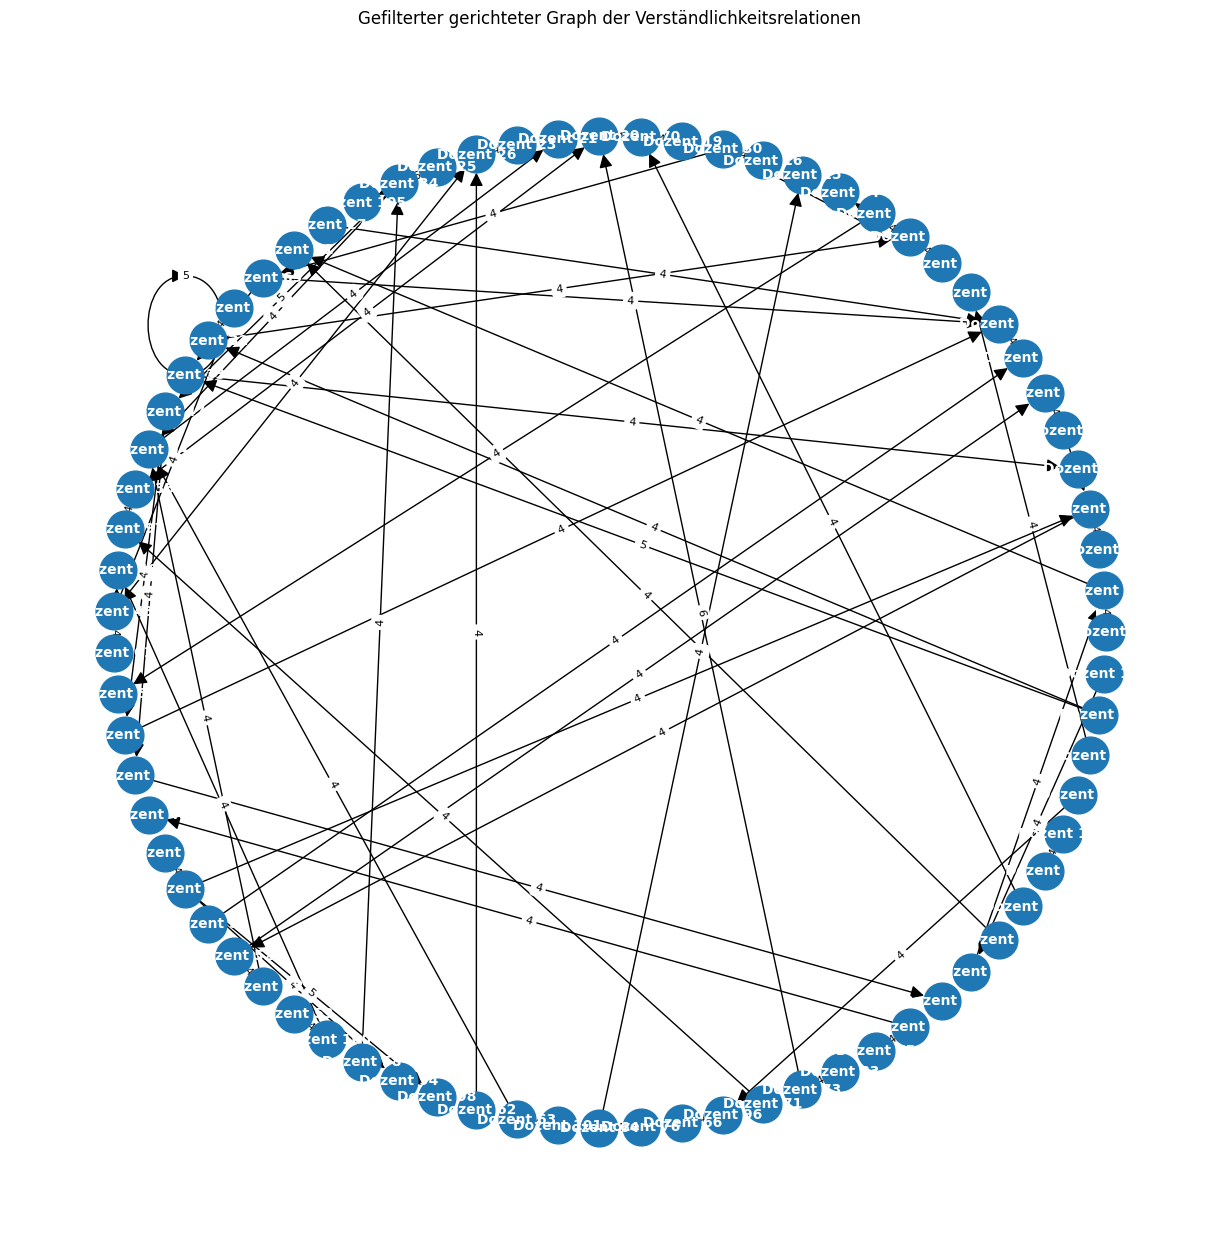

In [19]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

def filter_graph_by_threshold(matrix_path, threshold):
    # Lade die Matrix
    df = pd.read_csv(matrix_path)
    matrix = df.to_numpy()
    n = matrix.shape[0]
    
    # Erstelle einen gerichteten Graphen
    G = nx.DiGraph()
    for i in range(n):
        G.add_node(i, label=f"Dozent {i+1}")
        for j in range(n):
            if matrix[i, j] > threshold:
                G.add_edge(i, j, weight=matrix[i, j])
    
    # Entferne isolierte Knoten (Knoten ohne Kanten)
    isolated_nodes = list(nx.isolates(G))
    G.remove_nodes_from(isolated_nodes)
    
    return G

def visualize_graph(G):
    # Visualisiere den Graphen
    plt.figure(figsize=(12, 12))
    pos = nx.circular_layout(G)
    nx.draw(
        G,
        pos,
        with_labels=True,
        labels={node: data['label'] for node, data in G.nodes(data=True)},
        node_size=700,
        font_size=10,
        font_color="white",
        font_weight="bold",
        arrowsize=20
    )
    edge_labels = {(i, j): f"{d['weight']}" for i, j, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    plt.title("Gefilterter gerichteter Graph der Verständlichkeitsrelationen")
    plt.show()

# Beispielnutzung
matrix_path = 'Ergebnisse/LP_Verständlichkeit.csv'
threshold = 3
filtered_graph = filter_graph_by_threshold(matrix_path, threshold)
visualize_graph(filtered_graph)


⚠️ Zeige nur die ersten 500 von 5712 Kanten an.


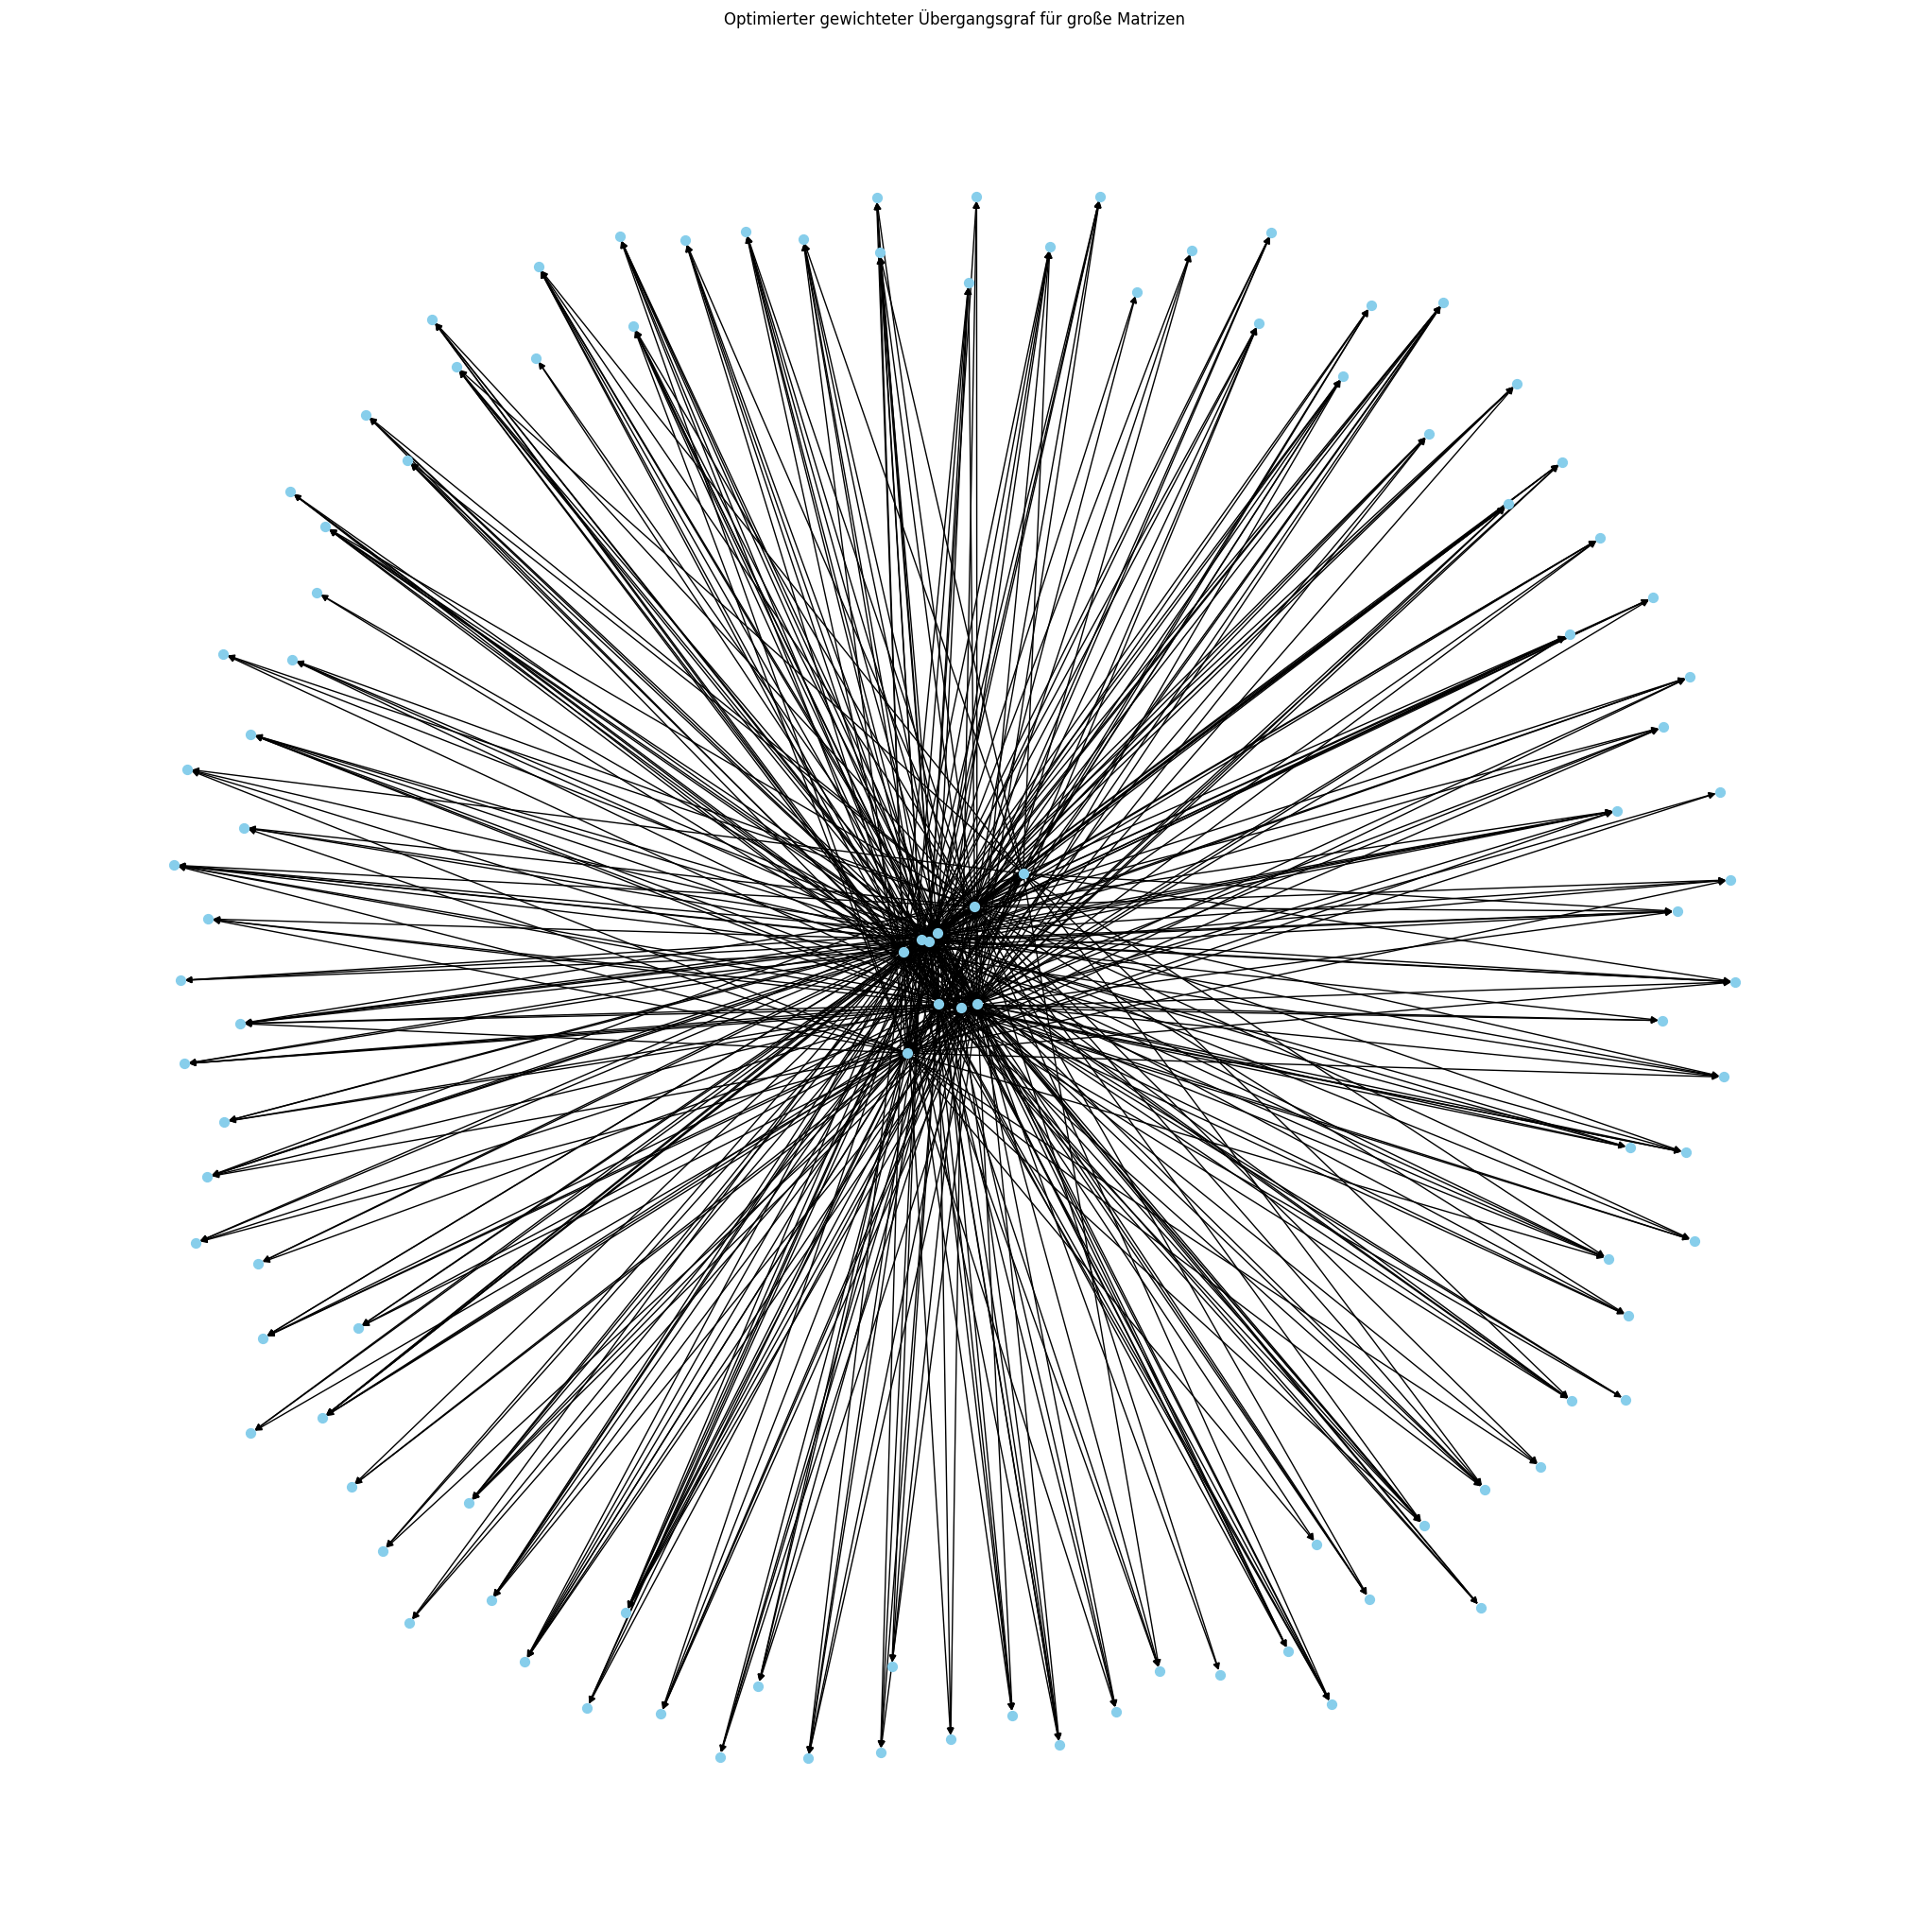

In [20]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def matrix_to_weighted_transition_graph(matrix):
    """
    Erstellt einen gewichteten gerichteten Übergangsgrafen aus einer Adjazenzmatrix.

    Parameter:
        matrix (list of lists or np.ndarray): Die gewichtete Adjazenzmatrix des Graphen.

    Rückgabe:
        G (networkx.DiGraph): Ein gewichteter gerichteter Graph.
    """
    matrix = np.array(matrix)
    m = matrix.shape[0]
    
    G = nx.DiGraph()
    
    for i in range(m):
        G.add_node(i)
    
    for i in range(m):
        for j in range(m):
            if matrix[i][j] != 0:
                G.add_edge(i, j, weight=matrix[i][j])
    
    return G

def draw_large_weighted_graph(G, max_edges=500):
    """
    Zeichnet einen großen gewichteten gerichteten Graphen mit Optimierungen.
    
    Parameter:
        G (networkx.DiGraph): Der gewichtete gerichtete Graph.
        max_edges (int): Maximale Anzahl der angezeigten Kanten.
    """
    # Reduziere die Anzahl der gezeichneten Kanten
    edges = list(G.edges(data=True))
    if len(edges) > max_edges:
        edges = edges[:max_edges]
        print(f"⚠️ Zeige nur die ersten {max_edges} von {len(G.edges())} Kanten an.")
    
    H = nx.DiGraph()
    H.add_edges_from(edges)
    
    # Verwende ein kraftbasiertes Layout
    pos = nx.spring_layout(H, k=0.1, iterations=50)
    
    # Zeichne den Graphen
    plt.figure(figsize=(20, 20))
    nx.draw(
        H, pos,
        with_labels=False,
        node_size=50,
        node_color='skyblue',
        font_size=8,
        font_color='black',
        arrowsize=10
    )
    
    # Kantenbeschriftungen (nur bei sehr wenigen Kanten anzeigen)
    if len(edges) < 100:
        edge_labels = nx.get_edge_attributes(H, 'weight')
        nx.draw_networkx_edge_labels(H, pos, edge_labels=edge_labels, font_size=8)
    
    plt.title("Optimierter gewichteter Übergangsgraf für große Matrizen")
    plt.show()

# Beispielmatrix (100x100, zufällige Einträge)
large_matrix = pd.read_csv('Ergebnisse/LP_Verständlichkeit.csv', header=None)

# Erstelle und zeichne den großen gewichteten Übergangsgrafen
G_large = matrix_to_weighted_transition_graph(large_matrix)
draw_large_weighted_graph(G_large, max_edges=500)
